# Do molecules with identical receptor barcodes smell the same?

Run on the **hybrid activation matrix**: 433 human olfactory receptors × 754 molecules,
where experimentally measured M2OR pairs carry their ground-truth value and every other
cell is the model prediction thresholded at the calibrated cut derived below.

Under combinatorial coding (Malnic et al. 1999, *Cell*) odour identity *is* the pattern of
receptor activation, so two molecules with an identical **barcode** should be perceptually
indistinguishable. That is falsifiable and needs a complete receptor × molecule map.

**Pipeline**
1. Build the hybrid matrix (ground truth substituted, predictions elsewhere)
2. Look at it **from the molecule side**
3. Split molecules into identical-barcode groups vs unique barcodes
4. Map `SMLxxxx` → SMILES / InChIKey → odour descriptors
5. Test whether identical-barcode molecules share perception, controlling for chemistry

*Model-behaviour / sanity analysis — supplementary, not a headline result.*

## Paths

Edit this block only. Everything downstream uses these four variables.

In [1]:
from pathlib import Path
from collections import defaultdict
import warnings
import numpy as np, pandas as pd
import matplotlib as mpl, matplotlib.pyplot as plt
from scipy import stats
warnings.filterwarnings("ignore")

import sys
sys.path.append("../../scripts")
from plotting_functions import custom_plots, FIGSIZE
plt.rcParams.update(custom_plots())

PATH_PROB  = "../../predictions/aggregated/Reference_Tree_Predictions/reference_median_probability_wide.csv"
PATH_M2OR  = "../../../Model/Data_Preparation/processed/m2or_pairs_model.csv"
PATH_ODORS = "../../predictions/aggregated/ASR_Predictions_RefTree/inchi_smiles_odors.csv"
PATH_FASTA = "../../../Phylogenetic_Analysis/data/ReferenceTree/PF13853.9606_7955_7740_7764_75743_137246.fa"

FIG = Path("Figures_barcodes"); FIG.mkdir(parents=True, exist_ok=True)
OUT = Path("Tables_barcodes");  OUT.mkdir(parents=True, exist_ok=True)

SPECIES_PREFIX = "9606."   # human
# THRESHOLD is derived from the measured pairs in the next cell, as in 01 and 02.

SAME_COL, DIFF_COL, ACCENT = "#7f1734", "#9a9a9a", "#2f6f5e"

def save(fig, name):
    fig.savefig(FIG / f"{name}.svg", bbox_inches="tight", transparent=True)
    print("wrote", FIG / f"{name}.svg")

## Build the hybrid matrix

The experimental override is keyed on **exact amino-acid sequence identity**, never on
UniProt accession. Mutant receptors in M2OR share the parent accession but differ in
sequence, so sequence matching excludes them automatically; accession matching would fold
mutant measurements onto wild-type predictions and inflate the correction.

Expected: **23,782** overlapping human receptor–ligand pairs across **409** receptors.

In [2]:
def read_fasta(path):
    seqs, h = {}, None
    for line in open(path):
        line = line.strip()
        if line.startswith(">"):
            h = line[1:].split()[0]; seqs[h] = []
        elif h:
            seqs[h].append(line)
    return {k: "".join(v) for k, v in seqs.items()}

prob  = pd.read_csv(PATH_PROB, index_col=0)
m2or  = pd.read_csv(PATH_M2OR)
odors = pd.read_csv(PATH_ODORS)
fasta = read_fasta(PATH_FASTA)

human_rows = [i for i in prob.index if str(i).startswith(SPECIES_PREFIX)]
P_hum = prob.loc[human_rows]

seq2pid = {v: k for k, v in fasta.items() if k.startswith(SPECIES_PREFIX)}
mh = m2or[m2or["Species"].str.lower().str.strip() == "homo sapiens"].copy()
mh["pid"] = mh["Sequence"].map(seq2pid)             # <- sequence identity, not UniProt ID
overlap = mh.dropna(subset=["pid"])
truth = overlap.groupby(["pid", "smiles_id"])["Responsive"].max()   # any positive assay wins

# Calibrated cut: predicted binding proportion == measured, on the measured cells.
_y = np.array([v for (pid, sid), v in truth.items() if pid in P_hum.index and sid in P_hum.columns])
_p = np.array([P_hum.at[pid, sid] for (pid, sid) in truth.index if pid in P_hum.index and sid in P_hum.columns])
_grid = np.arange(0.50, 0.9990, 0.0001)
THRESHOLD = float(_grid[np.abs(np.array([(_p > t).mean() for t in _grid]) - _y.mean()).argmin()])
print(f"calibrated threshold   : {THRESHOLD:.4f}  (measured binding proportion {_y.mean():.4%})")

pred_only = (P_hum > THRESHOLD).astype(np.int8)     # predictions alone, for comparison
hybrid    = pred_only.copy()

is_truth = pd.DataFrame(0, index=hybrid.index, columns=hybrid.columns, dtype=np.int8)
applied = 0
for (pid, sid), val in truth.items():
    if pid in hybrid.index and sid in hybrid.columns:
        hybrid.at[pid, sid] = int(val); is_truth.at[pid, sid] = 1; applied += 1

print(f"matrix                : {hybrid.shape[0]} human receptors x {hybrid.shape[1]} molecules")
print(f"ground-truth pairs     : {applied:,} over {int((is_truth.sum(axis=1) > 0).sum())} receptors")
print(f"cells changed by truth : {int((hybrid.values != pred_only.values).sum()):,}")
print(f"active cells           : predictions {int(pred_only.values.sum()):,} "
      f"-> hybrid {int(hybrid.values.sum()):,}")
print(f"hybrid density         : {hybrid.values.mean():.1%}")

calibrated threshold   : 0.9150  (measured binding proportion 4.7431%)
matrix                : 433 human receptors x 754 molecules
ground-truth pairs     : 23,782 over 409 receptors
cells changed by truth : 912
active cells           : predictions 6,468 -> hybrid 6,468
hybrid density         : 2.0%


wrote Figures_barcodes/hybrid_matrix_provenance.svg


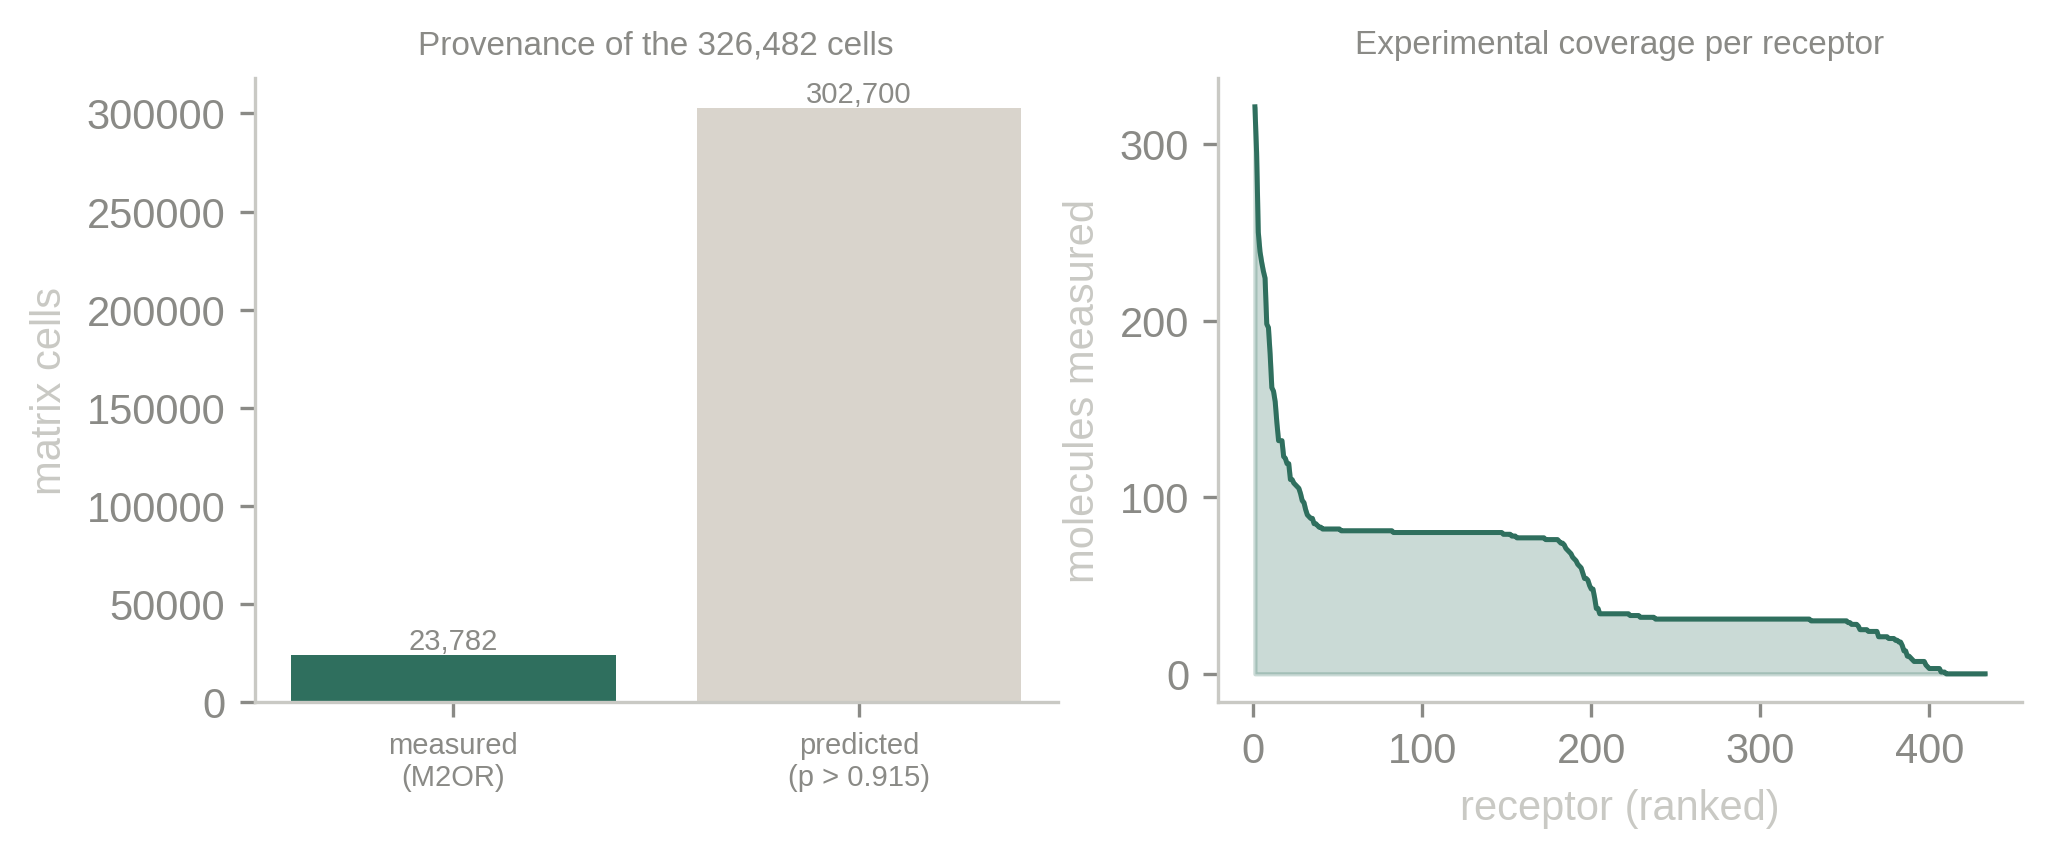

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(7.6, 2.7))
ax = axes[0]
ax.bar([0, 1], [is_truth.values.sum(), is_truth.size - is_truth.values.sum()],
       color=[ACCENT, "#d9d4cc"])
ax.set_xticks([0, 1]); ax.set_xticklabels(["measured\n(M2OR)", f"predicted\n(p > {THRESHOLD:.3f})"], fontsize=7)
ax.set_ylabel("matrix cells")
ax.set_title(f"Provenance of the {is_truth.size:,} cells", fontsize=8)
for x, v in zip([0, 1], [is_truth.values.sum(), is_truth.size - is_truth.values.sum()]):
    ax.text(x, v, f"{v:,}", ha="center", va="bottom", fontsize=7)

ax = axes[1]
cov = is_truth.sum(axis=1).sort_values(ascending=False).values
ax.plot(np.arange(1, len(cov) + 1), cov, color=ACCENT, lw=1.2)
ax.fill_between(np.arange(1, len(cov) + 1), cov, color=ACCENT, alpha=.25)
ax.set_xlabel("receptor (ranked)"); ax.set_ylabel("molecules measured")
ax.set_title("Experimental coverage per receptor", fontsize=8)
save(fig, "hybrid_matrix_provenance")

## The matrix from the molecule side

A molecule's **barcode** is its column: which of the 433 receptors it activates.

In [4]:
def barcode_table(B):
    V = B.values.astype(bool)
    return pd.DataFrame({
        "molecule": B.columns,
        "n_receptors": V.sum(axis=0),
        "barcode": [V[:, j].tobytes() for j in range(V.shape[1])],
    }).set_index("molecule")

tbl = barcode_table(hybrid)
silent = tbl.n_receptors == 0
live = tbl[~silent]
counts = live.barcode.value_counts()
n_unique_mols = int((counts == 1).sum())
n_groups = int((counts > 1).sum())
n_coll_mols = int(counts[counts > 1].sum())

summary = pd.Series({
    "receptors": hybrid.shape[0],
    "molecules": hybrid.shape[1],
    "median receptors / molecule": int(tbl.n_receptors.median()),
    "-- MOLECULES --": "",
    "mol: unique barcode": n_unique_mols,
    "mol: in collision groups": n_coll_mols,
    "mol: silent (no receptor)": int(silent.sum()),
    "mol: TOTAL": n_unique_mols + n_coll_mols + int(silent.sum()),
    "-- BARCODES --": "",
    "code: one-off": n_unique_mols,
    "code: shared (= n groups)": n_groups,
    "code: all-zero": int(silent.sum() > 0),
    "code: TOTAL distinct": int(tbl.barcode.nunique()),
})
print(summary.to_string())
print()
print("'mol: unique barcode' counts MOLECULES; 'code: TOTAL distinct' counts BARCODE VALUES")
print("(each collision group contributes one value however many molecules hold it).")

receptors                      433
molecules                      754
median receptors / molecule      6
-- MOLECULES --                   
mol: unique barcode            389
mol: in collision groups       272
mol: silent (no receptor)       93
mol: TOTAL                     754
-- BARCODES --                    
code: one-off                  389
code: shared (= n groups)       65
code: all-zero                   1
code: TOTAL distinct           455

'mol: unique barcode' counts MOLECULES; 'code: TOTAL distinct' counts BARCODE VALUES
(each collision group contributes one value however many molecules hold it).


**Silent molecules** activate no receptor, so they all share the all-zero barcode. That is
an *absence* of a code, not a shared code — they are excluded from every collision
analysis below, otherwise they would form one large spurious group.

wrote Figures_barcodes/molecule_side_overview.svg


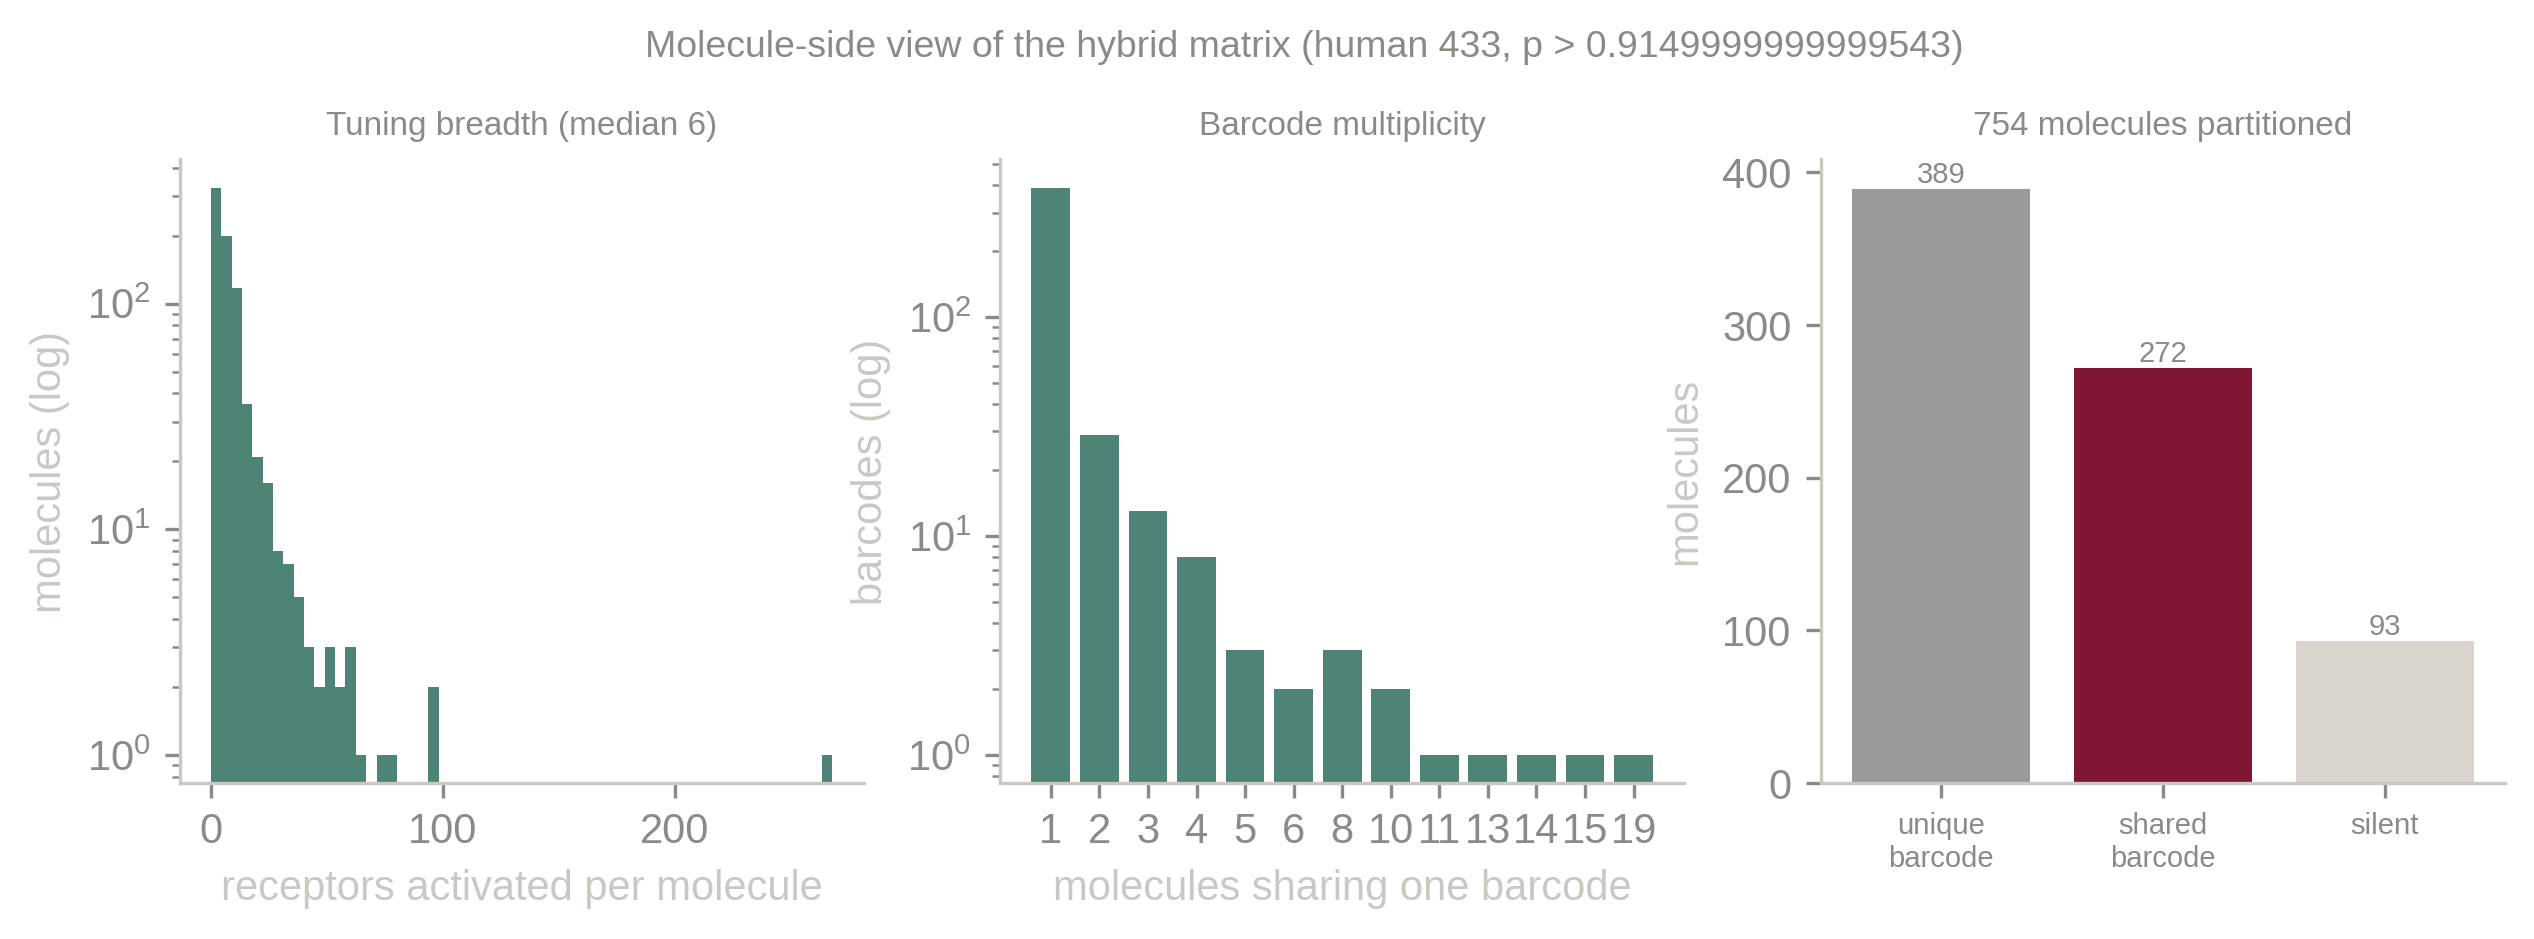

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(10, 2.7))

ax = axes[0]
ax.hist(tbl.n_receptors, bins=60, color=ACCENT, alpha=.85)
ax.set_yscale("log")
ax.set_xlabel("receptors activated per molecule"); ax.set_ylabel("molecules (log)")
ax.set_title(f"Tuning breadth (median {int(tbl.n_receptors.median())})", fontsize=8)

ax = axes[1]
grp = counts.value_counts().sort_index()
ax.bar(grp.index.astype(str), grp.values, color=ACCENT, alpha=.85)
ax.set_yscale("log")
ax.set_xlabel("molecules sharing one barcode"); ax.set_ylabel("barcodes (log)")
ax.set_title("Barcode multiplicity", fontsize=8)

ax = axes[2]
vals = [n_unique_mols, n_coll_mols, int(silent.sum())]
ax.bar([0, 1, 2], vals, color=[DIFF_COL, SAME_COL, "#d9d4cc"])
ax.set_xticks([0, 1, 2])
ax.set_xticklabels(["unique\nbarcode", "shared\nbarcode", "silent"], fontsize=7)
ax.set_ylabel("molecules"); ax.set_title(f"{hybrid.shape[1]} molecules partitioned", fontsize=8)
for x, v in zip([0, 1, 2], vals):
    ax.text(x, v, str(v), ha="center", va="bottom", fontsize=7)

fig.suptitle(f"Molecule-side view of the hybrid matrix (human 433, p > {THRESHOLD})",
             fontsize=9, y=1.04)
save(fig, "molecule_side_overview")

## Split: identical barcodes vs unique barcodes

- **`df_identical`** — molecules whose barcode is shared by ≥1 other molecule, with a `group_id`
- **`df_unique`** — molecules holding their barcode alone
- **`df_silent`** — molecules activating no receptor

In [6]:
gid = {bc: f"G{n:03d}" for n, bc in enumerate(
    counts[counts > 1].sort_values(ascending=False).index, start=1)}
live = live.copy()
live["group_id"] = live.barcode.map(gid)
live["group_size"] = live.barcode.map(counts)

df_identical = (live[live.group_id.notna()]
                .sort_values(["group_size", "group_id"], ascending=[False, True]))
df_unique = live[live.group_id.isna()].drop(columns=["group_id"])
df_silent = tbl[silent]

print(f"df_identical : {len(df_identical)} molecules in {df_identical.group_id.nunique()} groups")
print(f"df_unique    : {len(df_unique)} molecules")
print(f"df_silent    : {len(df_silent)} molecules")
print()
print(df_identical.groupby("group_id")
      .agg(size=("group_size", "first"), n_receptors=("n_receptors", "first"))
      .sort_values("size", ascending=False).head(12).to_string())

df_identical : 272 molecules in 65 groups
df_unique    : 389 molecules
df_silent    : 93 molecules

          size  n_receptors
group_id                   
G001        19            1
G002        15            7
G003        14            2
G004        13            3
G005        11            1
G006        10            1
G007        10            8
G008         8            4
G009         8            8
G010         8            4
G011         6            3
G012         6            6


## Map SMLxxxx → SMILES / InChIKey → perception

`m2or_pairs_model.csv` gives the one-to-one `smiles_id` → SMILES mapping;
`inchi_smiles_odors.csv` joins SMILES to InChIKey and the odour descriptor list.

In [7]:
sml2smiles = m2or[["SMILES", "smiles_id"]].drop_duplicates()
chem = (sml2smiles.merge(odors, on="SMILES", how="left")
        .rename(columns={"smiles_id": "molecule"})
        .set_index("molecule"))
chem["tags"] = chem.Odors.fillna("").apply(
    lambda s: frozenset(t.strip().lower() for t in str(s).split(",") if t.strip()))
chem["n_tags"] = chem.tags.apply(len)

print(f"mapped {chem.index.nunique()} / {hybrid.shape[1]} molecules")
print(f"with >=1 descriptor : {(chem.n_tags > 0).sum()}")
print(f"vocabulary          : {len({t for s in chem.tags for t in s})} terms")
print(f"descriptors / molecule: median {int(chem.n_tags.median())}, max {chem.n_tags.max()}")

for df in (df_identical, df_unique):
    for col in ("SMILES", "InChIKey", "Odors", "tags", "n_tags"):
        df[col] = chem[col].reindex(df.index)

df_identical.drop(columns=["barcode"]).to_csv(OUT / "identical_barcode_molecules.csv")
df_unique.drop(columns=["barcode"]).to_csv(OUT / "unique_barcode_molecules.csv")
print("\nwrote tables to", OUT)

mapped 754 / 754 molecules
with >=1 descriptor : 575
vocabulary          : 147 terms
descriptors / molecule: median 5, max 16

wrote tables to Tables_barcodes


## The identical-barcode groups

A group defined by 20 co-activated receptors is a far stronger claim of shared coding than
one defined by a single receptor, so group specificity matters as much as group size.

wrote Figures_barcodes/identical_barcode_groups.svg


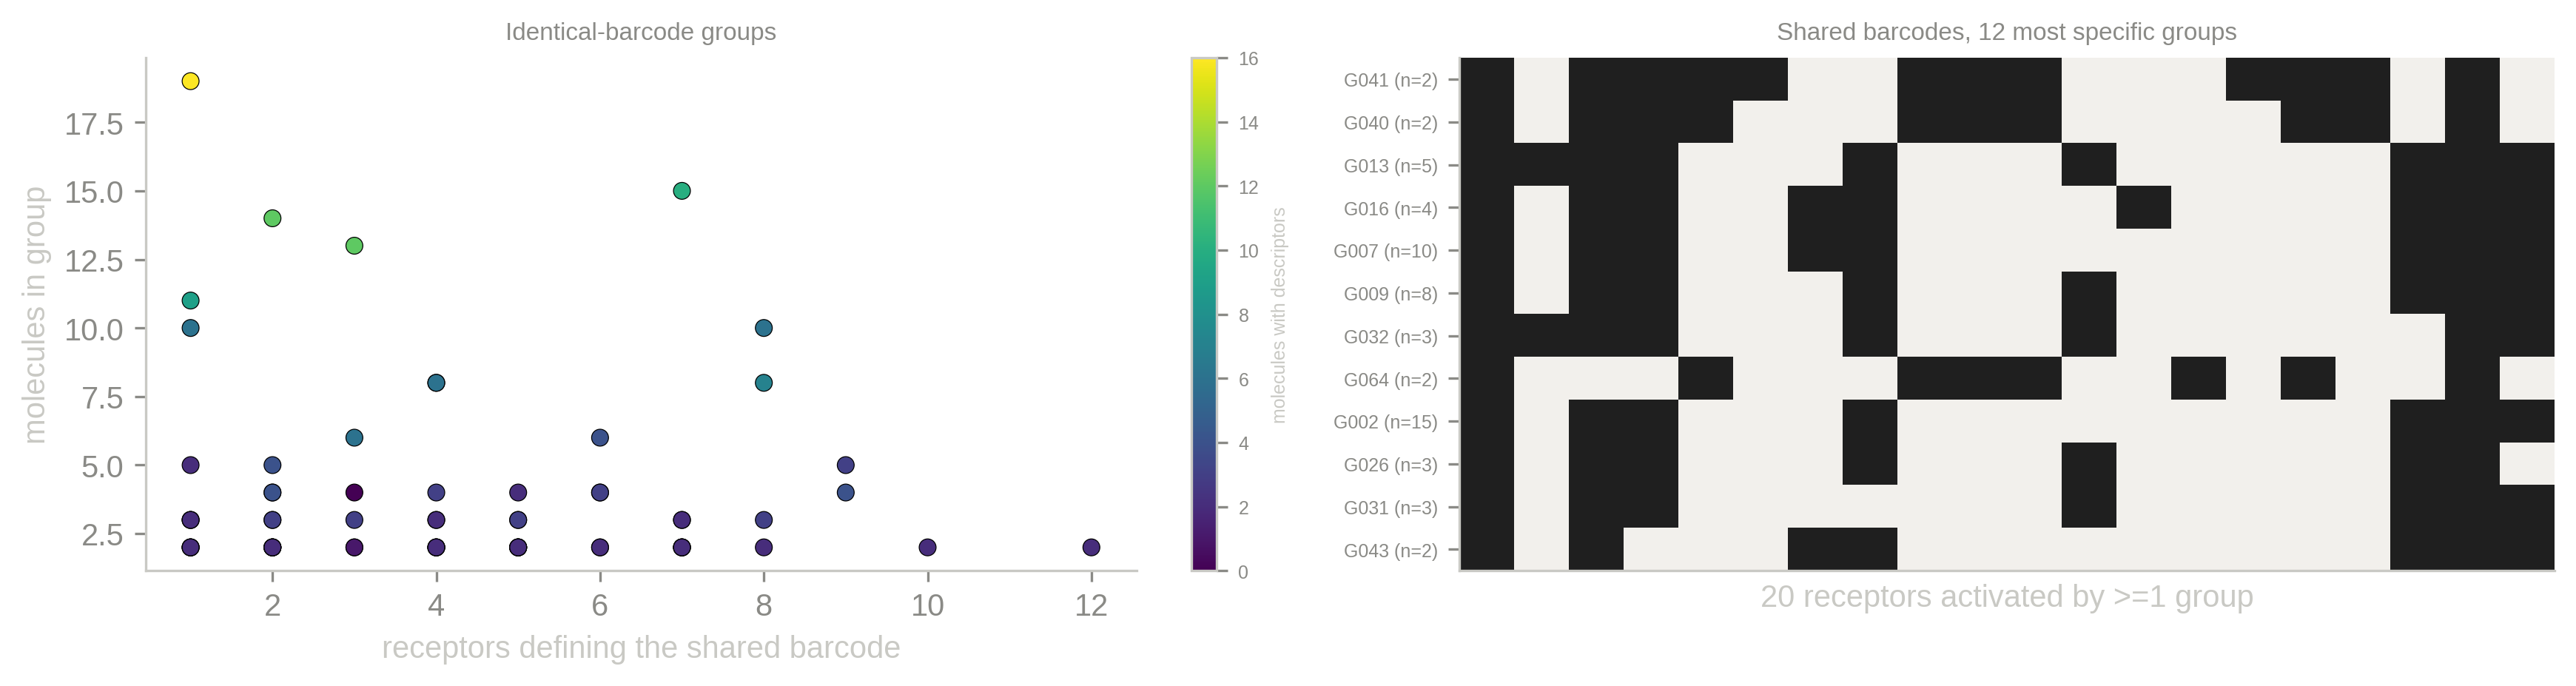

In [8]:
grp_info = (df_identical.groupby("group_id")
            .agg(size=("group_size", "first"),
                 n_receptors=("n_receptors", "first"),
                 n_tagged=("n_tags", lambda v: int((v > 0).sum())))
            .sort_values(["n_receptors", "size"], ascending=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 3.0))
ax = axes[0]
sc = ax.scatter(grp_info.n_receptors, grp_info["size"], s=30, c=grp_info.n_tagged,
                cmap="viridis", edgecolor="k", linewidth=.3)
#ax.set_xscale("symlog")
ax.set_xlabel("receptors defining the shared barcode"); ax.set_ylabel("molecules in group")
cb = fig.colorbar(sc, ax=ax, fraction=.045); cb.set_label("molecules with descriptors", size=6)
cb.ax.tick_params(labelsize=6)
ax.set_title("Identical-barcode groups", fontsize=8)

ax = axes[1]
top = grp_info.head(12).index
Bv = hybrid.values.astype(bool)
rows_ = [Bv[:, hybrid.columns.get_loc(df_identical[df_identical.group_id == g].index[0])]
         for g in top]
Rm = np.array(rows_); keep = Rm.any(axis=0)
ax.imshow(Rm[:, keep], aspect="auto", interpolation="nearest",
          cmap=mpl.colors.ListedColormap(["#f2f0ec", "#1f1f1f"]))
ax.set_yticks(range(len(top)))
ax.set_yticklabels([f"{g} (n={grp_info.loc[g, 'size']})" for g in top], fontsize=6)
ax.set_xticks([]); ax.set_xlabel(f"{int(keep.sum())} receptors activated by >=1 group")
ax.set_title("Shared barcodes, 12 most specific groups", fontsize=8)
save(fig, "identical_barcode_groups")

## Do identical barcodes mean identical perception?

Pairwise Jaccard overlap of descriptor sets within groups, against random pairs from the
same pool. Only molecules carrying ≥1 descriptor are used.

In [9]:
def tag_jaccard(a, b):
    if not a and not b: return np.nan
    return len(a & b) / len(a | b)

tagged = set(chem[chem.n_tags > 0].index)

same_pairs = []
for g, sub in df_identical.groupby("group_id"):
    mols = [m for m in sub.index if m in tagged]
    for i in range(len(mols)):
        for j in range(i + 1, len(mols)):
            a, b = mols[i], mols[j]
            same_pairs.append(dict(group_id=g, mol_a=a, mol_b=b,
                                   n_receptors=int(sub.n_receptors.iloc[0]),
                                   jaccard=tag_jaccard(chem.tags[a], chem.tags[b])))
same_pairs = pd.DataFrame(same_pairs).dropna(subset=["jaccard"])

rng = np.random.default_rng(0)
pool = [m for m in hybrid.columns if m in tagged]
rand = np.array([tag_jaccard(chem.tags[a], chem.tags[b])
                 for a, b in (rng.choice(pool, 2, replace=False) for _ in range(20000))])
rand = rand[~np.isnan(rand)]

u = stats.mannwhitneyu(same_pairs.jaccard, rand, alternative="greater")
cliff = 2 * u.statistic / (len(same_pairs) * len(rand)) - 1
share_same = (same_pairs.jaccard > 0).mean(); share_rand = (rand > 0).mean()
print(f"identical-barcode pairs : n = {len(same_pairs)}, median {same_pairs.jaccard.median():.3f}, "
      f"mean {same_pairs.jaccard.mean():.3f}")
print(f"random pairs            : n = {len(rand)}, median {np.median(rand):.3f}, mean {rand.mean():.3f}")
print(f"Mann-Whitney (greater)  : p = {u.pvalue:.3g}, Cliff's delta = {cliff:+.3f}")
print(f"sharing >=1 descriptor  : {share_same:.1%} vs {share_rand:.1%}")
same_pairs.to_csv(OUT / "within_group_pair_similarity.csv", index=False)

identical-barcode pairs : n = 521, median 0.077, mean 0.101
random pairs            : n = 20000, median 0.043, mean 0.067
Mann-Whitney (greater)  : p = 2.41e-13, Cliff's delta = +0.174
sharing >=1 descriptor  : 61.0% vs 50.1%


wrote Figures_barcodes/barcode_vs_perception.svg


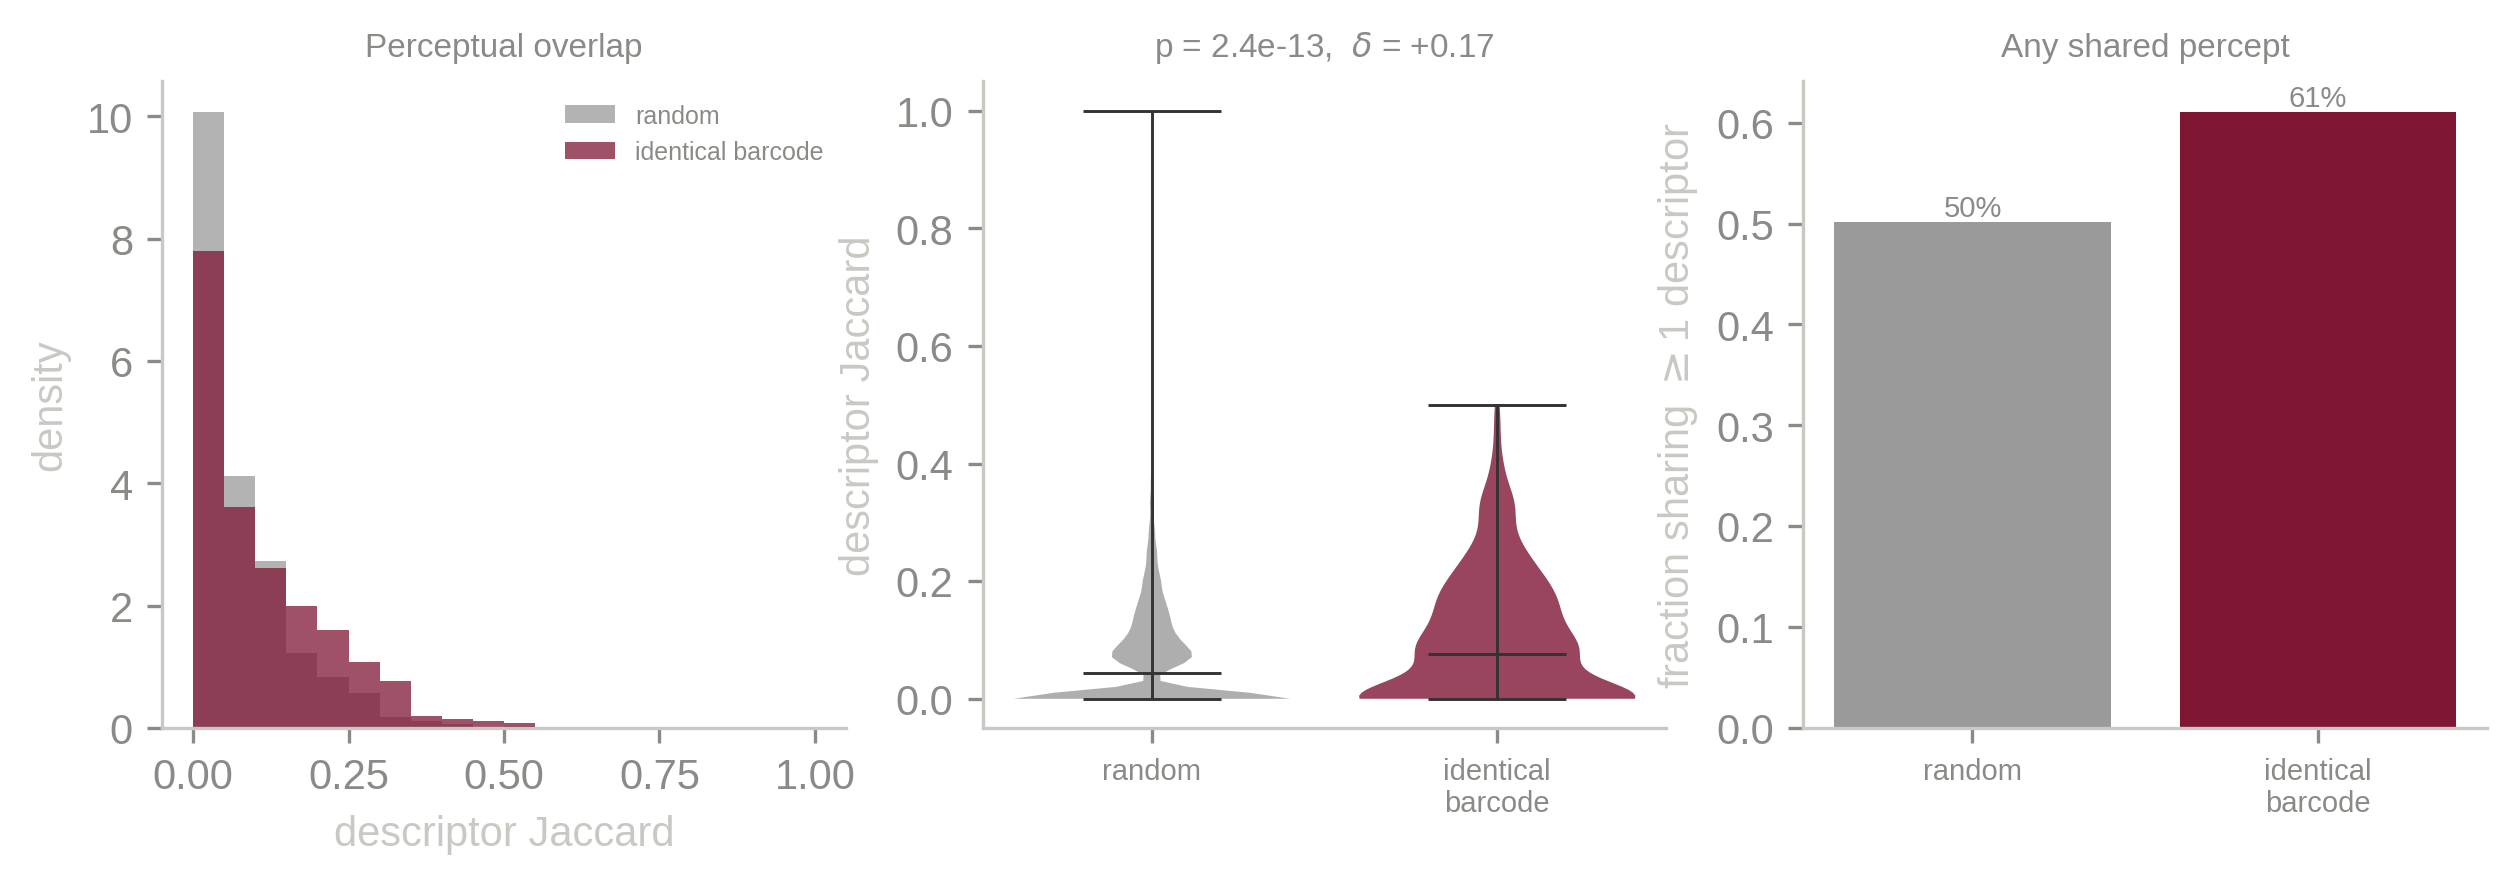

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(10, 2.8))
bins = np.linspace(0, 1, 21)
ax = axes[0]
ax.hist(rand, bins=bins, density=True, color=DIFF_COL, alpha=.75, label="random")
ax.hist(same_pairs.jaccard, bins=bins, density=True, color=SAME_COL, alpha=.75,
        label="identical barcode")
ax.set_xlabel("descriptor Jaccard"); ax.set_ylabel("density")
ax.legend(fontsize=6, frameon=False); ax.set_title("Perceptual overlap", fontsize=8)

ax = axes[1]
parts = ax.violinplot([rand, same_pairs.jaccard.values], showmedians=True, widths=.8)
for pc, c in zip(parts["bodies"], (DIFF_COL, SAME_COL)):
    pc.set_facecolor(c); pc.set_alpha(.8); pc.set_edgecolor("none")
for k in ("cbars", "cmins", "cmaxes", "cmedians"):
    parts[k].set_color("#333"); parts[k].set_linewidth(.7)
ax.set_xticks([1, 2]); ax.set_xticklabels(["random", "identical\nbarcode"], fontsize=7)
ax.set_ylabel("descriptor Jaccard")
ax.set_title(f"p = {u.pvalue:.2g},  $\\delta$ = {cliff:+.2f}", fontsize=8)

ax = axes[2]
ax.bar([0, 1], [share_rand, share_same], color=[DIFF_COL, SAME_COL])
ax.set_xticks([0, 1]); ax.set_xticklabels(["random", "identical\nbarcode"], fontsize=7)
ax.set_ylabel("fraction sharing $\\geq$1 descriptor")
for x, v in zip([0, 1], [share_rand, share_same]):
    ax.text(x, v, f"{v:.0%}", ha="center", va="bottom", fontsize=7)
ax.set_title("Any shared percept", fontsize=8)
save(fig, "barcode_vs_perception")

## Group-level inspection

Which descriptors do the identical-barcode molecules actually agree on?

In [11]:
records = []
for g, sub in df_identical.groupby("group_id"):
    mols = [m for m in sub.index if m in tagged]
    if len(mols) < 2: continue
    sets = [set(chem.tags[m]) for m in mols]
    inter, union = set.intersection(*sets), set.union(*sets)
    records.append(dict(group_id=g, n_molecules=len(mols),
                        n_receptors=int(sub.n_receptors.iloc[0]),
                        shared_descriptors=", ".join(sorted(inter)) or "-",
                        n_shared=len(inter), n_union=len(union),
                        consensus=len(inter) / len(union) if union else np.nan))
group_perception = (pd.DataFrame(records)
                    .sort_values(["n_receptors", "n_shared"], ascending=False))
group_perception.to_csv(OUT / "group_shared_descriptors.csv", index=False)
print(group_perception.head(15).to_string(index=False))

group_id  n_molecules  n_receptors            shared_descriptors  n_shared  n_union  consensus
    G041            2           12 alliaceous, coffee, sulfurous         3       16   0.187500
    G040            2           10                             -         0       10   0.000000
    G013            3            9                   fatty, waxy         2       17   0.117647
    G016            4            9                             -         0       14   0.000000
    G064            2            8   earthy, green, musty, nutty         4       10   0.400000
    G032            3            8                 fatty, fruity         2       19   0.105263
    G007            6            8                             -         0       26   0.000000
    G009            7            8                             -         0       36   0.000000
    G031            2            7                 citrus, fresh         2        8   0.250000
    G048            2            7                

In [12]:
for g in group_perception.head(6).group_id:
    sub = df_identical[(df_identical.group_id == g) & (df_identical.n_tags > 0)]
    r = group_perception[group_perception.group_id == g].iloc[0]
    print(f"\n=== {g} | {r.n_molecules} molecules | barcode = {r.n_receptors} receptors"
          f" | shared: {r.shared_descriptors}")
    for m, row in sub.iterrows():
        print(f"   {m}  {str(row.SMILES)[:42]:<42}  {row.Odors}")


=== G041 | 2 molecules | barcode = 12 receptors | shared: alliaceous, coffee, sulfurous
   SML0329  C1=COC(=C1)CS                               coffee, alliaceous, fatty, chicken, oily, smoky, burnt, meaty, caramellic, savory, sulfurous
   SML0346  C1=CC=C(C=C1)CS                             minty, coffee, alliaceous, sharp, onion, garlic, horseradish, sulfurous

=== G040 | 2 molecules | barcode = 10 receptors | shared: -
   SML0344  CSCC1=CC=CC=C1                              chicken, burnt, meaty, beefy, roasted, savory, horseradish, sulfurous
   SML0465  CCOC1=CC=CC=C1                              anisic, sweet

=== G013 | 3 molecules | barcode = 9 receptors | shared: fatty, waxy
   SML0020  CCCCCCCCCCCC(=O)OCC                         clean, soapy, fatty, oily, sweet, floral, waxy, fruity
   SML0039  CCCCCCCCCCCCCC(=O)OC                        fatty, orris, oily, cognac, waxy
   SML0336  CCCCCCCC(=O)C                               weedy, soapy, herbal, cheesy, fatty, sweet, coconut

## Control: is this just chemical similarity?

Molecules sharing a barcode may simply be chemically near-identical, and similar molecules
trivially share descriptors. The predictor's ligand arm is also a structure embedding
(MolFormer), so structurally similar molecules can receive similar predicted barcodes by
construction. The result only means something if it survives **within** structurally
dissimilar pairs — so we stratify by Morgan-fingerprint Tanimoto.

In [13]:
from rdkit import Chem as rdChem, RDLogger, DataStructs
from rdkit.Chem import rdFingerprintGenerator
RDLogger.DisableLog("rdApp.*")

gen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)
fps = {}
for m, s in chem.SMILES.items():
    mol = rdChem.MolFromSmiles(s) if isinstance(s, str) else None
    if mol is not None: fps[m] = gen.GetFingerprint(mol)

same_pairs["tanimoto"] = [
    DataStructs.TanimotoSimilarity(fps[a], fps[b]) if a in fps and b in fps else np.nan
    for a, b in zip(same_pairs.mol_a, same_pairs.mol_b)]

rng = np.random.default_rng(1)
rand_rows = []
for _ in range(20000):
    a, b = rng.choice(pool, 2, replace=False)
    if a in fps and b in fps:
        rand_rows.append(dict(jaccard=tag_jaccard(chem.tags[a], chem.tags[b]),
                              tanimoto=DataStructs.TanimotoSimilarity(fps[a], fps[b])))
rand_df = pd.DataFrame(rand_rows).dropna()

BINS = [(0.0, 0.2, "0.0-0.2 (very different)"),
        (0.2, 0.4, "0.2-0.4 (different)"),
        (0.4, 1.01, "0.4-1.0 (similar)")]
rows_ = []
for lo, hi, lab in BINS:
    s = same_pairs[(same_pairs.tanimoto >= lo) & (same_pairs.tanimoto < hi)].jaccard.dropna()
    r = rand_df[(rand_df.tanimoto >= lo) & (rand_df.tanimoto < hi)].jaccard.dropna()
    if len(s) < 5:
        rows_.append(dict(bin=lab, n_same=len(s))); continue
    rows_.append(dict(bin=lab, n_same=len(s), same_mean=s.mean(), same_median=s.median(),
                      n_rand=len(r), rand_mean=r.mean(), rand_median=r.median(),
                      same_any=(s > 0).mean(), rand_any=(r > 0).mean(),
                      p=stats.mannwhitneyu(s, r, alternative="greater").pvalue))
strat = pd.DataFrame(rows_)
strat.to_csv(OUT / "stratified_by_structure.csv", index=False)
print(strat.round(4).to_string(index=False))

                     bin  n_same  same_mean  same_median  n_rand  rand_mean  rand_median  same_any  rand_any      p
0.0-0.2 (very different)     347     0.0727       0.0625   17173     0.0588       0.0000    0.5360    0.4734 0.0021
     0.2-0.4 (different)     117     0.1232       0.1176    2382     0.1160       0.0909    0.6923    0.7045 0.1650
       0.4-1.0 (similar)      57     0.2304       0.2222     445     0.1936       0.1667    0.8947    0.8584 0.0022


wrote Figures_barcodes/structure_control.svg


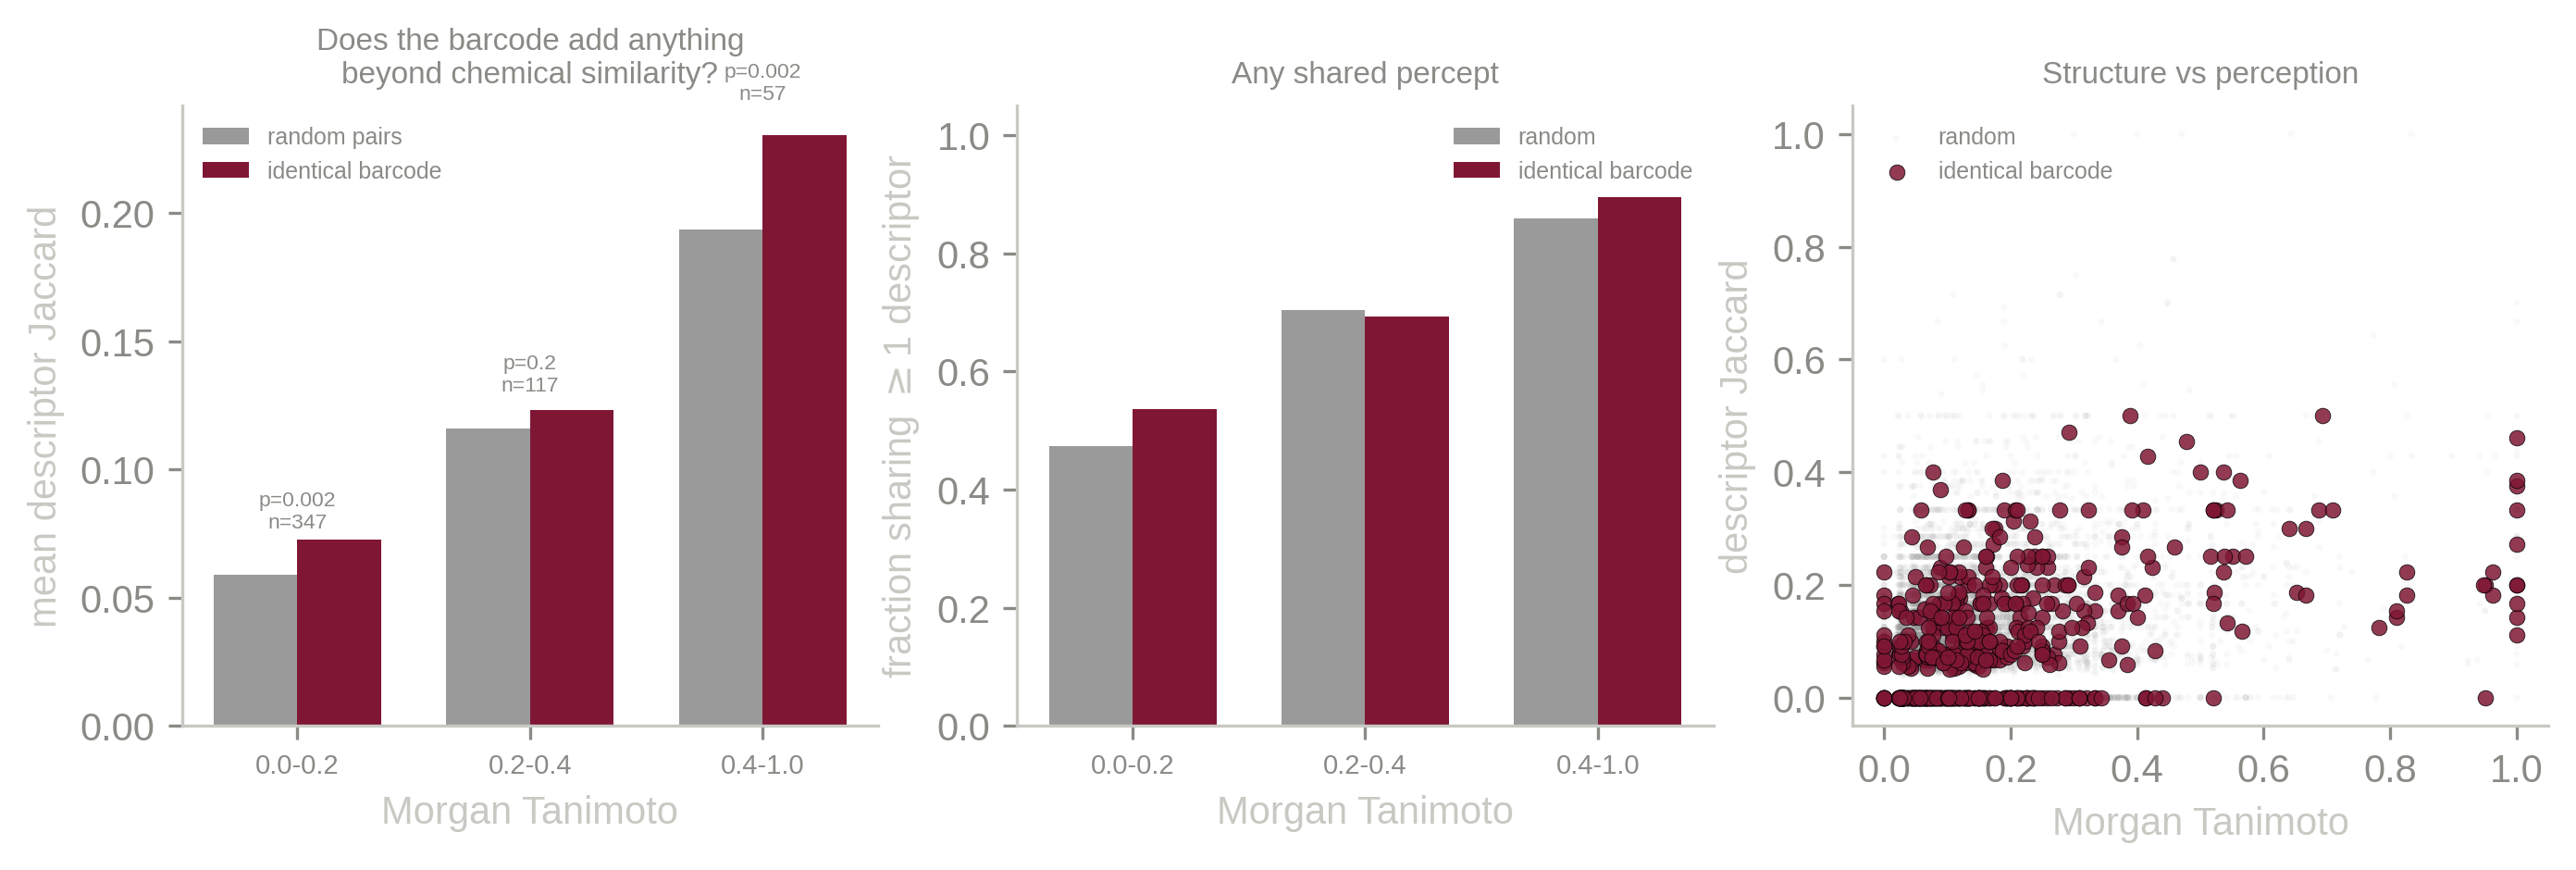

In [14]:
ok = strat.dropna(subset=["same_mean"])
fig, axes = plt.subplots(1, 3, figsize=(11, 2.9))

ax = axes[0]
x = np.arange(len(ok)); w = .36
ax.bar(x - w/2, ok.rand_mean, w, color=DIFF_COL, label="random pairs")
ax.bar(x + w/2, ok.same_mean, w, color=SAME_COL, label="identical barcode")
ax.set_xticks(x); ax.set_xticklabels([b.split(" (")[0] for b in ok.bin], fontsize=7)
ax.set_xlabel("Morgan Tanimoto"); ax.set_ylabel("mean descriptor Jaccard")
ax.legend(fontsize=6, frameon=False)
for xi in range(len(ok)):
    ax.text(xi, max(ok.rand_mean.iloc[xi], ok.same_mean.iloc[xi]) * 1.06,
            f"p={ok.p.iloc[xi]:.1g}\nn={ok.n_same.iloc[xi]}", ha="center", fontsize=5.5)
ax.set_title("Does the barcode add anything\nbeyond chemical similarity?", fontsize=8)

ax = axes[1]
ax.bar(x - w/2, ok.rand_any, w, color=DIFF_COL, label="random")
ax.bar(x + w/2, ok.same_any, w, color=SAME_COL, label="identical barcode")
ax.set_xticks(x); ax.set_xticklabels([b.split(" (")[0] for b in ok.bin], fontsize=7)
ax.set_xlabel("Morgan Tanimoto"); ax.set_ylabel("fraction sharing $\\geq$1 descriptor")
ax.legend(fontsize=6, frameon=False); ax.set_ylim(0, 1.05)
ax.set_title("Any shared percept", fontsize=8)

ax = axes[2]
ax.scatter(rand_df.tanimoto, rand_df.jaccard, s=3, alpha=.06, color=DIFF_COL,
           edgecolor="none", label="random")
ax.scatter(same_pairs.tanimoto, same_pairs.jaccard, s=16, alpha=.85, color=SAME_COL,
           edgecolor="k", linewidth=.2, label="identical barcode")
ax.set_xlabel("Morgan Tanimoto"); ax.set_ylabel("descriptor Jaccard")
ax.legend(fontsize=6, frameon=False, loc="upper left")
ax.set_title("Structure vs perception", fontsize=8)
save(fig, "structure_control")

## Threshold sensitivity

Barcode identity is a hard equality on a thresholded matrix, so a pair differing by one
receptor at the threshold ± 0.01 is called "different". This shows how brittle the partition is.
Ground-truth cells are unaffected by the threshold — only predicted cells move.

In [15]:
alt = {}
for t in (round(THRESHOLD - 0.03, 3), round(THRESHOLD, 3), round(THRESHOLD + 0.03, 3)):
    h = (P_hum > t).astype(np.int8)
    for (pid, sid), val in truth.items():
        if pid in h.index and sid in h.columns:
            h.at[pid, sid] = int(val)
    tt = barcode_table(h); lv = tt[tt.n_receptors > 0]; c = lv.barcode.value_counts()
    alt[t] = dict(silent=int((tt.n_receptors == 0).sum()),
                  unique_molecules=int((c == 1).sum()),
                  groups=int((c > 1).sum()),
                  molecules_in_groups=int(c[c > 1].sum()))
print(pd.DataFrame(alt).to_string())

                     0.885  0.915  0.945
silent                  57     93    142
unique_molecules       457    389    291
groups                  66     65     60
molecules_in_groups    240    272    321


## Interpretation

Read off §8:

- **Effect survives in the 0.0–0.2 Tanimoto bin** → molecules that look nothing alike but
  share a receptor code also share perception. Genuine support for combinatorial coding,
  and indirect support for the model.
- **Effect vanishes once structure is controlled** → identical predicted barcodes track
  chemical similarity rather than an independent perceptual code. Expected given the
  structure-based predictor; a statement about the model, not about olfaction.

**Limits to state**

- Collision groups are enriched for narrowly-tuned molecules (few receptors → easier to
  collide), so they are not a random sample of chemical space.
- Descriptor vocabularies (Leffingwell / GoodScents) are curated at uneven granularity, so
  set Jaccard understates true perceptual agreement.
- Cells carrying ground truth are sparse relative to the full matrix, so most barcode bits
  are still model predictions even in the hybrid.